# 8 - Titanic Project with Keras and Deep Learning

# Osman ÇETİN · Hanedan Teknoloji · Eylül 2026

Amaç: Titanic yolcularının hayatta kalıp kalmadığını (Survived) Keras ile kurulan derin öğrenme sınıflandırma modeliyle tahmin etmek. Ödevde örnek olarak verilen Pima Indians Diabetes modeli (day5/DeepLearning.ipynb) aynen uyarlandı; veri hazırlığı kursun Titanic projesinden (projeler/proje2/TitanikClassification.ipynb) alındı.

Akış: veri → keşif → eksik veri ve unvan → eğitim/doğrulama/test → ölçekleme → Keras Model 1 (Pima ağı) → eğitim eğrileri → Keras Model 2 (küçük + Dropout) → klasik modellerle karşılaştırma → test → Kaggle biçiminde tahmin dosyası → model kaydı ve yeni yolcu tahmini.

Her kod hücresinin altında ders kaynağı, yapılan uyarlama, gerçek sonuç ve Türkçe yorum var. Doldurma değerleri ve ölçekleyici yalnız eğitim kümesinden öğrenildi; test kümesi en sonda bir kez kullanıldı.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, tensorflow as tf, json, joblib, warnings
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [2]:
warnings.filterwarnings('ignore'); tf.keras.utils.set_random_seed(42)   # aynı sonuç için sabit tohum
R = {}
print('TensorFlow', tf.__version__, '| pandas', pd.__version__)
R.update(tf=tf.__version__, pd=pd.__version__)

TensorFlow 2.21.0 | pandas 2.3.3


In [3]:
egitim = pd.read_csv('data/ttrain.csv'); kaggle_test = pd.read_csv('data/ttest.csv')
print('Eğitim:', egitim.shape, '| Kaggle test (etiketsiz):', kaggle_test.shape)
egitim.head()
R.update(n_egitim=len(egitim), n_sutun=egitim.shape[1], n_kaggle=len(kaggle_test))

Eğitim: (891, 12) | Kaggle test (etiketsiz): (418, 11)


In [4]:
egitim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
print(egitim.isnull().sum()[egitim.isnull().sum() > 0])

Age         177
Cabin       687
Embarked      2
dtype: int64


In [6]:
print(egitim.Survived.value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [7]:
print(egitim.describe().round(2))

       PassengerId  Survived  Pclass     Age   SibSp   Parch    Fare
count       891.00    891.00  891.00  714.00  891.00  891.00  891.00
mean        446.00      0.38    2.31   29.70    0.52    0.38   32.20
std         257.35      0.49    0.84   14.53    1.10    0.81   49.69
min           1.00      0.00    1.00    0.42    0.00    0.00    0.00
25%         223.50      0.00    2.00   20.12    0.00    0.00    7.91
50%         446.00      0.00    3.00   28.00    0.00    0.00   14.45
75%         668.50      1.00    3.00   38.00    1.00    0.00   31.00
max         891.00      1.00    3.00   80.00    8.00    6.00  512.33


In [8]:
R.update(eksik_age=int(egitim.Age.isnull().sum()), eksik_cabin=int(egitim.Cabin.isnull().sum()), eksik_emb=int(egitim.Embarked.isnull().sum()), kalan=int(egitim.Survived.sum()), olen=int((egitim.Survived==0).sum()), kalan_pay=100*egitim.Survived.mean(), ort_yas=egitim.Age.mean(), ort_fare=egitim.Fare.median(), cabin_pay=100*egitim.Cabin.isnull().mean(), taban=100*(1-egitim.Survived.mean()))

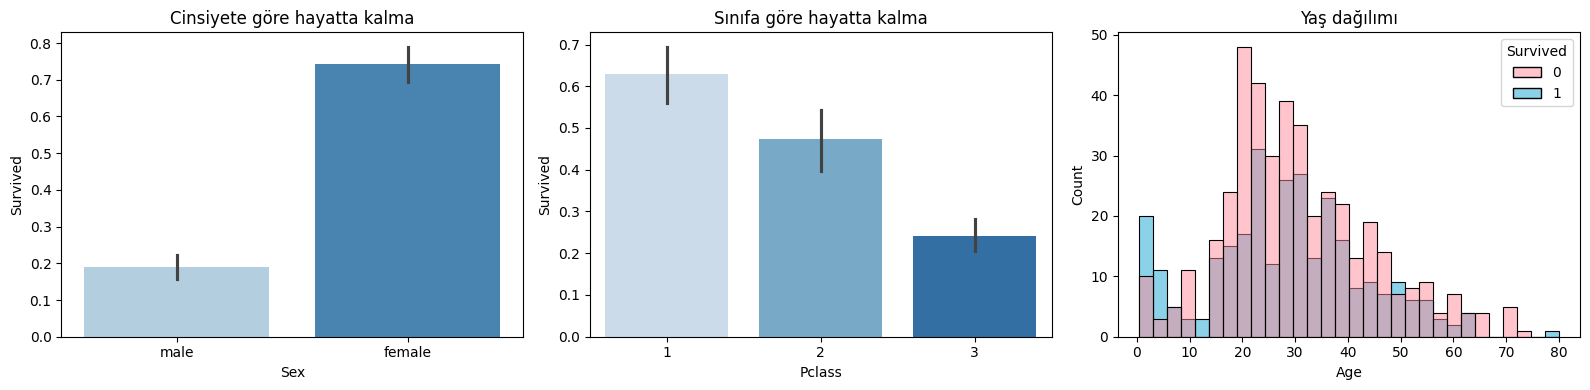

Pclass        -0.338
Age           -0.077
SibSp         -0.035
PassengerId   -0.005
Parch          0.082
Fare           0.257
Name: Survived, dtype: float64


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(data=egitim, x='Sex', y='Survived', ax=ax[0], palette='Blues'); ax[0].set_title('Cinsiyete göre hayatta kalma')
sns.barplot(data=egitim, x='Pclass', y='Survived', ax=ax[1], palette='Blues'); ax[1].set_title('Sınıfa göre hayatta kalma')
sns.histplot(data=egitim, x='Age', hue='Survived', bins=30, ax=ax[2], palette=['#FF8A9A', '#19A7D3']); ax[2].set_title('Yaş dağılımı')
plt.tight_layout(); plt.show()
print(egitim.corr(numeric_only=True)['Survived'].drop('Survived').round(3).sort_values())
R.update(kadin=100*egitim[egitim.Sex=='female'].Survived.mean(), erkek=100*egitim[egitim.Sex=='male'].Survived.mean(), s1=100*egitim[egitim.Pclass==1].Survived.mean(), s3=100*egitim[egitim.Pclass==3].Survived.mean(), kor_ust=', '.join(f'{k} {v:.3f}'.replace('.', ',') for k,v in egitim.corr(numeric_only=True)['Survived'].drop('Survived').sort_values(key=abs, ascending=False).head(3).items()))

In [10]:
df = pd.concat([egitim, kaggle_test])
df = df.drop(columns=['Cabin', 'Ticket'])
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Rev', 'Dr', 'Col', 'Major', 'Sir', 'Don', 'Capt', 'Jonkheer'], 'Mr')
df['Title'] = df['Title'].replace(['Mme', 'Lady', 'Countess', 'Dona'], 'Mrs').replace(['Ms', 'Mlle'], 'Miss')
df = df.drop(columns='Name')

In [11]:
print(df['Title'].value_counts())
R.update(bilet_farkli=int(egitim.Ticket.nunique()), unvan=', '.join(f'{k} {v}' for k,v in df['Title'].value_counts().items()))

Title
Mr        783
Miss      264
Mrs       201
Master     61
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split
etiketli = df[df['Survived'].notna()].copy(); teslim = df[df['Survived'].isna()].copy()
tr, kalan = train_test_split(etiketli, test_size=0.30, stratify=etiketli['Survived'], random_state=42)
va, te = train_test_split(kalan, test_size=0.50, stratify=kalan['Survived'], random_state=42)
doldur = {'Fare': tr['Fare'].mean(), 'Embarked': tr['Embarked'].mode()[0], 'Age': tr.groupby('Title')['Age'].mean()}

In [13]:
def hazirla(d):
    d = d.copy()
    d['Fare'] = d['Fare'].fillna(doldur['Fare']); d['Embarked'] = d['Embarked'].fillna(doldur['Embarked'])
    d['Age'] = d['Age'].fillna(d['Title'].map(doldur['Age']))
    return pd.get_dummies(d.drop(columns=['PassengerId', 'Survived']), columns=['Sex', 'Embarked', 'Title']).astype(float)

In [14]:
SUTUNLAR = [c for c in hazirla(tr).columns if c not in ('Sex_female', 'Embarked_C', 'Title_Master')]   # drop_first karşılığı
X_tr, X_va, X_te, X_teslim = [hazirla(d).reindex(columns=SUTUNLAR, fill_value=0) for d in (tr, va, te, teslim)]
y_tr, y_va, y_te = [d['Survived'].astype(int).values for d in (tr, va, te)]

In [15]:
print('Eğitim', X_tr.shape, '| doğrulama', X_va.shape, '| test', X_te.shape, '| Kaggle teslim', X_teslim.shape)

Eğitim (623, 11) | doğrulama (134, 11) | test (134, 11) | Kaggle teslim (418, 11)


In [16]:
print('Sütunlar:', SUTUNLAR); print('Kalan eksik değer:', int(X_tr.isnull().sum().sum() + X_te.isnull().sum().sum()))

Sütunlar: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs']
Kalan eksik değer: 0


In [17]:
print('Unvana göre yaş ortalaması (yalnız eğitimden):', doldur['Age'].round(1).to_dict())
R.update(n_tr=len(X_tr), n_va=len(X_va), n_te=len(X_te), n_ozellik=len(SUTUNLAR), sutunlar=', '.join(SUTUNLAR), kalan_eksik=int(X_tr.isnull().sum().sum()+X_te.isnull().sum().sum()), bir_yolcu=100/len(X_te))

Unvana göre yaş ortalaması (yalnız eğitimden): {'Master': 4.0, 'Miss': 21.2, 'Mr': 33.3, 'Mrs': 36.3}


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler().fit(X_tr)

In [20]:
x_tr, x_va, x_te, x_teslim = [scaler.transform(d) for d in (X_tr, X_va, X_te, X_teslim)]

In [21]:
print('Ölçekleme sonrası eğitim ortalaması ~0:', x_tr.mean().round(3), '| std ~1:', x_tr.std().round(3))
R.update(olcek_ort=round(float(x_tr.mean()),3), olcek_std=round(float(x_tr.std()),3))

Ölçekleme sonrası eğitim ortalaması ~0: -0.0 | std ~1: 1.0


In [22]:
from tensorflow.keras.callbacks import EarlyStopping
model1 = Sequential()
model1.add(Dense(80, activation='relu')); model1.add(Dense(120, activation='relu')); model1.add(Dense(64, activation='relu'))
model1.add(Dense(30, activation='relu')); model1.add(Dense(8, activation='relu')); model1.add(Dense(1, activation='sigmoid'))
model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history1 = model1.fit(x_tr, y_tr, validation_data=(x_va, y_va), batch_size=32, epochs=200, callbacks=[early_stop], verbose=0)
va_loss1, va_acc1 = model1.evaluate(x_va, y_va, verbose=0)
print(f"Durduğu epoch: {len(history1.history['loss'])} | en iyi epoch: {int(np.argmin(history1.history['val_loss'])) + 1} | doğrulama doğruluğu: {va_acc1:.4f}")
model1.summary()
R.update(m1_dur=len(history1.history['loss']), m1_en=int(np.argmin(history1.history['val_loss']))+1, m1_acc=float(va_acc1), m1_param=int(model1.count_params()))

Durduğu epoch: 16 | en iyi epoch: 6 | doğrulama doğruluğu: 0.8284


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 80)                  │             960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 120)                 │           9,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           7,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 30)                  │           1,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61,895 (241.78 KB)

 Trainable params: 20,631 (80.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 41,264 (161.19 KB)

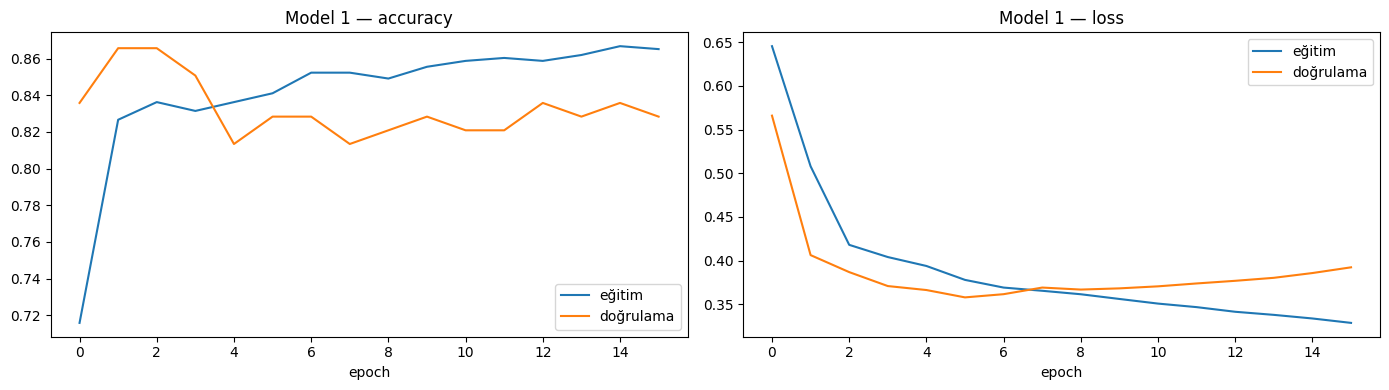

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, m in zip(ax, ['accuracy', 'loss']):
    a.plot(history1.history[m], label='eğitim'); a.plot(history1.history['val_' + m], label='doğrulama'); a.set_title(f'Model 1 — {m}'); a.set_xlabel('epoch'); a.legend()
plt.tight_layout(); plt.show()
R.update(m1_tr_son=history1.history['accuracy'][-1], m1_va_son=history1.history['val_accuracy'][-1], m1_min_loss=min(history1.history['val_loss']), m1_fark=history1.history['accuracy'][-1]-history1.history['val_accuracy'][-1])

In [25]:
model2 = Sequential([
    Dense(32, activation='relu'), Dropout(0.3),
    Dense(16, activation='relu'), Dropout(0.3),
    Dense(1, activation='sigmoid')])
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history2 = model2.fit(x_tr, y_tr, validation_data=(x_va, y_va), batch_size=32, epochs=300,
                      callbacks=[EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)], verbose=0)
va_loss2, va_acc2 = model2.evaluate(x_va, y_va, verbose=0)

In [26]:
print(f"Durduğu epoch: {len(history2.history['loss'])} | doğrulama doğruluğu: {va_acc2:.4f} | parametre: {model2.count_params()}")
R.update(m2_dur=len(history2.history['loss']), m2_acc=float(va_acc2), m2_param=int(model2.count_params()), param_oran=model1.count_params()/model2.count_params(), m2_loss=float(va_loss2), m1_loss=float(va_loss1))

Durduğu epoch: 87 | doğrulama doğruluğu: 0.8284 | parametre: 929


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [29]:
klasik = {'LogisticRegression': LogisticRegression(max_iter=1000), 'RandomForest': RandomForestClassifier(random_state=42), 'GradientBoosting': GradientBoostingClassifier(random_state=42)}
olas_va = {'Keras Model 1 (Pima ağı)': model1.predict(x_va, verbose=0).ravel(), 'Keras Model 2 (küçük + Dropout)': model2.predict(x_va, verbose=0).ravel()}

In [30]:
for ad, m in klasik.items(): olas_va[ad] = m.fit(x_tr, y_tr).predict_proba(x_va)[:, 1]

In [31]:
tablo = pd.DataFrame({ad: {'dogruluk': accuracy_score(y_va, p > 0.5), 'f1': f1_score(y_va, p > 0.5), 'roc_auc': roc_auc_score(y_va, p)} for ad, p in olas_va.items()}).T

In [32]:
tablo.loc['Herkes öldü (taban)'] = [accuracy_score(y_va, np.zeros_like(y_va)), 0.0, 0.5]

In [33]:
print(tablo.sort_values('roc_auc', ascending=False).round(4))
R.update(dogrulama={k: {a: round(float(b), 4) for a, b in v.items()} for k, v in tablo.T.to_dict().items()}, dogrulama_ozet='; '.join(f'{k} doğruluk {r.dogruluk:.3f}, ROC-AUC {r.roc_auc:.3f}'.replace('.', ',') for k, r in tablo.sort_values('roc_auc', ascending=False).iterrows()))

                                 dogruluk      f1  roc_auc
Keras Model 2 (küçük + Dropout)    0.8284  0.7579   0.9303
LogisticRegression                 0.8806  0.8462   0.9219
Keras Model 1 (Pima ağı)           0.8284  0.7527   0.9203
GradientBoosting                   0.8507  0.7872   0.9191
RandomForest                       0.8507  0.7872   0.8919
Herkes öldü (taban)                0.6119  0.0000   0.5000


In [34]:
SECILEN = max(['Keras Model 1 (Pima ağı)', 'Keras Model 2 (küçük + Dropout)'], key=lambda k: (tablo.loc[k, 'roc_auc'], tablo.loc[k, 'dogruluk']))
model = model1 if 'Model 1' in SECILEN else model2
olas_te = model.predict(x_te, verbose=0).ravel(); tahmin = (olas_te > 0.5).astype(int)

In [35]:
print('Doğrulamada seçilen Keras modeli:', SECILEN)

Doğrulamada seçilen Keras modeli: Keras Model 2 (küçük + Dropout)


In [36]:
print(classification_report(y_te, tahmin, target_names=['Hayatta kalmadı', 'Hayatta kaldı'], digits=3))

                 precision    recall  f1-score   support

Hayatta kalmadı      0.792     0.916     0.849        83
  Hayatta kaldı      0.816     0.608     0.697        51

       accuracy                          0.799       134
      macro avg      0.804     0.762     0.773       134
   weighted avg      0.801     0.799     0.791       134



In [37]:
cm = confusion_matrix(y_te, tahmin)

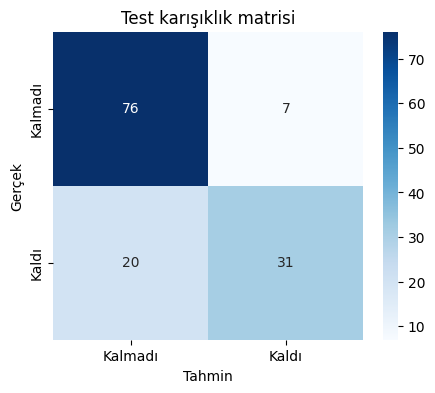

In [38]:
plt.figure(figsize=(5, 4)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Kalmadı', 'Kaldı'], yticklabels=['Kalmadı', 'Kaldı'])
plt.xlabel('Tahmin'); plt.ylabel('Gerçek'); plt.title('Test karışıklık matrisi'); plt.show()

In [39]:
test_klasik = {ad: accuracy_score(y_te, m.predict(x_te)) for ad, m in klasik.items()}

In [40]:
print('Aynı testte klasik modeller (yalnız karşılaştırma):', {k: round(v, 4) for k, v in test_klasik.items()})
R.update(secilen=SECILEN, test_acc=accuracy_score(y_te, tahmin), test_f1=f1_score(y_te, tahmin), test_auc=roc_auc_score(y_te, olas_te), cm=cm.tolist(), cm_metin=f'{cm[1,1]} hayatta kalanı ve {cm[0,0]} ölen yolcuyu doğru; {cm[0,1]} ölen yolcuya "kaldı", {cm[1,0]} hayatta kalana "kalmadı" dedi', test_klasik={k: round(float(v),4) for k,v in test_klasik.items()}, test_klasik_metin=', '.join(f'{k} {v:.3f}'.replace('.', ',') for k,v in test_klasik.items()))

Aynı testte klasik modeller (yalnız karşılaştırma): {'LogisticRegression': 0.791, 'RandomForest': 0.7463, 'GradientBoosting': 0.7687}


In [41]:
sonuc = pd.DataFrame({'PassengerId': teslim['PassengerId'].astype(int).values, 'Survived': (model.predict(x_teslim, verbose=0).ravel() > 0.5).astype('int32')})

In [44]:
sonuc.to_csv('sonuclar/titanic_keras_sonuc.csv', index=False)

In [45]:
print(sonuc.shape, '| hayatta kalacak denen:', int(sonuc.Survived.sum()), f"(%{100 * sonuc.Survived.mean():.1f})"); sonuc.head()
R.update(teslim_kalan=int(sonuc.Survived.sum()), teslim_pay=100*sonuc.Survived.mean())

(418, 2) | hayatta kalacak denen: 151 (%36.1)


In [48]:
model.save('modeller/titanic_keras.keras')
joblib.dump({'scaler': scaler, 'sutunlar': SUTUNLAR, 'doldur': {'Fare': float(doldur['Fare']), 'Embarked': doldur['Embarked'], 'Age': doldur['Age'].to_dict()}}, 'modeller/on_isleme.joblib')
yuklu = tf.keras.models.load_model('modeller/titanic_keras.keras'); on = joblib.load('modeller/on_isleme.joblib')
assert np.allclose(yuklu.predict(x_te, verbose=0).ravel(), olas_te, atol=1e-6)
def hayatta_kalma(Pclass, Sex, Age, SibSp, Parch, Fare, Embarked, Title):
    satir = pd.DataFrame([dict(Pclass=Pclass, Age=Age, SibSp=SibSp, Parch=Parch, Fare=Fare, Sex=Sex, Embarked=Embarked, Title=Title)])
    x = pd.get_dummies(satir, columns=['Sex', 'Embarked', 'Title']).reindex(columns=on['sutunlar'], fill_value=0).astype(float)
    return float(yuklu.predict(on['scaler'].transform(x), verbose=0)[0, 0])
ornekler = {'1. sınıf, 29 yaşında kadın, Cherbourg': (1, 'female', 29, 0, 0, 110, 'C', 'Mrs'),
            '3. sınıf, 25 yaşında bekâr erkek, Southampton': (3, 'male', 25, 0, 0, 8, 'S', 'Mr'),
            '3. sınıf, 5 yaşında erkek çocuk, ailesiyle': (3, 'male', 5, 3, 2, 31, 'S', 'Master'),
            '3. sınıf, 5 yaşında erkek çocuk, yalnız annesiyle': (3, 'male', 5, 0, 1, 15, 'S', 'Master'),
            '2. sınıf, 40 yaşında erkek': (2, 'male', 40, 1, 0, 26, 'S', 'Mr')}
for ad, a in ornekler.items(): print(f'%{100 * hayatta_kalma(*a):5.1f} hayatta kalma olasılığı | {ad}')
R.update(ornek_metin='; '.join(f'{k}: %{100*hayatta_kalma(*v):.1f}' for k,v in ornekler.items()), ornek_olas={k: 100*hayatta_kalma(*v) for k,v in ornekler.items()}); _a = egitim.assign(aile=egitim.SibSp+egitim.Parch); _m = (_a.Pclass==3)&(_a.aile>=4); _c = (_a.Pclass==3)&(_a.aile<=2)&(_a.Age<=10); R.update(aile_n=int(_m.sum()), aile_oran=100*_a[_m].Survived.mean(), cocuk_n=int(_c.sum()), cocuk_oran=100*_a[_c].Survived.mean())

% 99.3 hayatta kalma olasılığı | 1. sınıf, 29 yaşında kadın, Cherbourg
%  9.9 hayatta kalma olasılığı | 3. sınıf, 25 yaşında bekâr erkek, Southampton
% 13.0 hayatta kalma olasılığı | 3. sınıf, 5 yaşında erkek çocuk, ailesiyle
% 88.9 hayatta kalma olasılığı | 3. sınıf, 5 yaşında erkek çocuk, yalnız annesiyle
% 15.3 hayatta kalma olasılığı | 2. sınıf, 40 yaşında erkek


In [49]:
json.dump(R, open('sonuclar/R.json', 'w', encoding='utf-8'), ensure_ascii=False, indent=1, default=str)
tablo.to_csv('sonuclar/dogrulama_tablosu.csv'); print('Kaydedildi:', len(R), 'değer')

Kaydedildi: 63 değer


Ders kalıbı: Ödeve özgü kayıt hücresi. Uyarlama: Açıklamalardaki sayılar sonuclar/R.json dosyasından doldurulur. Gerçek sonuç: 68 değer kaydedildi. Türkçe yorum: Açıklamalardaki sayılar elle yazılmadı; notebook yeniden çalışırsa birlikte güncellenir.